<a href="https://colab.research.google.com/github/shubhamraut0209/Data-Science-Projects-Simplilearn/blob/main/Employee_Turnover_Analytics_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Shubham Umesh Raut | Machine Learning using Python | 15 August 2024 | Employee Turnover Analytics**

# ***DESCRIPTION***

**Background of Problem Statement :**


> Portobello Tech is an app innovator that has devised an intelligent way of predicting employee turnover within the company. It periodically evaluates employees' work details, including the number of projects they worked on, average monthly working hours, time spent in the company, promotions in the last five years, and salary level. Data from prior evaluations show the employees' satisfaction in the workplace. The data could be used to identify patterns in work style and their interest in continuing to work for the company. The HR Department owns the data and uses it to predict employee turnover. Employee turnover refers to the total number of workers who leave a company over time.

**Project Objective :**


> The objective of this project is to develop a machine learning model that can predict employee turnover based on various work related factors. By analyzing historical employee data, the model will identify key factors contributing to employee retention and turnover, allowing the HR Department to proactively address issues and implement effective retention strategies.



**Primary Domain :** Human Resources (HR) Analytics

***Specific Focus Area :*** Employee Retention and Turnover Prediction

**Dataset Description :**


*   **satisfaction_level :-** Satisfaction level at the job of an employee

*   **last_evaluation :-** Rating between 0 and 1. received by an employee at his last evaluation

*   **number_project :-** The number of projects an employee is involved in

*   **average_montly_hours :-** Average number of hours in a month spent by an employee at the office.

*   **time_spend_company :-** Number of years spent in the company

*   **Work_accident :-**
       

1.   **0 =** indicates no accident during employee stay.
2.   **1 =** indicates accident during employee stay.

*   **left :-**


1.   **0 =** indicates an employee stays with the company.
2.   **1 =** indicates an employee left the company.

*   **promotion_last_5years :-** Number of promotions in his stay.


*   **Department :-** Department to which an employee belongs to

*   **Salary :-** Salary in USD

**Analysis Tasks**

As the ML Developer assigned to the HR Department, you have been asked to create ML programs to:

1. Perform data quality checks by checking for missing values, if any.

2. Understand what factors contributed most to employee turnover at EDA.

3. Perform clustering of employees who left based on their satisfaction and evaluation.

4. Handle the left Class Imbalance using the SMOTE technique.

5. Perform k-fold cross-validation model training and evaluate performance.

6. Identify the best model and justify the evaluation metrics used.

7. Suggest various retention strategies for targeted employees.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df= pd.read_excel("/content/HR_comma_sep.xlsx")

In [ ]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [ ]:
df.isna().sum()

,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_montly_hours,0
time_spend_company,0
Work_accident,0
left,0
promotion_last_5years,0
sales,0
salary,0


In [ ]:
df["left"].unique()

array([1, 0])

In [ ]:
df["promotion_last_5years"].unique()

array([0, 1])

In [ ]:
df["number_project"].unique()

array([2, 5, 7, 6, 4, 3])

In [ ]:
df.satisfaction_level.unique()

array([0.38, 0.8 , 0.11, 0.72, 0.37, 0.41, 0.1 , 0.92, 0.89, 0.42, 0.45,
       0.84, 0.36, 0.78, 0.76, 0.09, 0.46, 0.4 , 0.82, 0.87, 0.57, 0.43,
       0.13, 0.44, 0.39, 0.85, 0.81, 0.9 , 0.74, 0.79, 0.17, 0.24, 0.91,
       0.71, 0.86, 0.14, 0.75, 0.7 , 0.31, 0.73, 0.83, 0.32, 0.54, 0.27,
       0.77, 0.88, 0.48, 0.19, 0.6 , 0.12, 0.61, 0.33, 0.56, 0.47, 0.28,
       0.55, 0.53, 0.59, 0.66, 0.25, 0.34, 0.58, 0.51, 0.35, 0.64, 0.5 ,
       0.23, 0.15, 0.49, 0.3 , 0.63, 0.21, 0.62, 0.29, 0.2 , 0.16, 0.65,
       0.68, 0.67, 0.22, 0.26, 0.99, 0.98, 1.  , 0.52, 0.93, 0.97, 0.69,
       0.94, 0.96, 0.18, 0.95])

In [ ]:
df.last_evaluation.unique()

array([0.53, 0.86, 0.88, 0.87, 0.52, 0.5 , 0.77, 0.85, 1.  , 0.54, 0.81,
       0.92, 0.55, 0.56, 0.47, 0.99, 0.51, 0.89, 0.83, 0.95, 0.57, 0.49,
       0.46, 0.62, 0.94, 0.48, 0.8 , 0.74, 0.7 , 0.78, 0.91, 0.93, 0.98,
       0.97, 0.79, 0.59, 0.84, 0.45, 0.96, 0.68, 0.82, 0.9 , 0.71, 0.6 ,
       0.65, 0.58, 0.72, 0.67, 0.75, 0.73, 0.63, 0.61, 0.76, 0.66, 0.69,
       0.37, 0.64, 0.39, 0.41, 0.43, 0.44, 0.36, 0.38, 0.4 , 0.42])

In [ ]:
df.time_spend_company.unique()

array([ 3,  6,  4,  5,  2,  8, 10,  7])

In [ ]:
df.Work_accident.unique()

array([0, 1])

In [ ]:
df.sales.unique()

array(['sales', 'accounting', 'hr', 'technical', 'support', 'management',
       'IT', 'product_mng', 'marketing', 'RandD'], dtype=object)

In [ ]:
df.salary.unique()

array(['low', 'medium', 'high'], dtype=object)

In [ ]:
numeric_df= df.select_dtypes(include=[np.number])

In [ ]:
numeric_df.corr()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
satisfaction_level,1.000000,0.105021,-0.142970,-0.020048,-0.100866,0.058697,-0.388375,0.025605
last_evaluation,0.105021,1.000000,0.349333,0.339742,0.131591,-0.007104,0.006567,-0.008684
number_project,-0.142970,0.349333,1.000000,0.417211,0.196786,-0.004741,0.023787,-0.006064
average_montly_hours,-0.020048,0.339742,0.417211,1.000000,0.127755,-0.010143,0.071287,-0.003544
time_spend_company,-0.100866,0.131591,0.196786,0.127755,1.000000,0.002120,0.144822,0.067433
Work_accident,0.058697,-0.007104,-0.004741,-0.010143,0.002120,1.000000,-0.154622,0.039245
left,-0.388375,0.006567,0.023787,0.071287,0.144822,-0.154622,1.000000,-0.061788
promotion_last_5years,0.025605,-0.008684,-0.006064,-0.003544,0.067433,0.039245,-0.061788,1.000000


<Axes: >

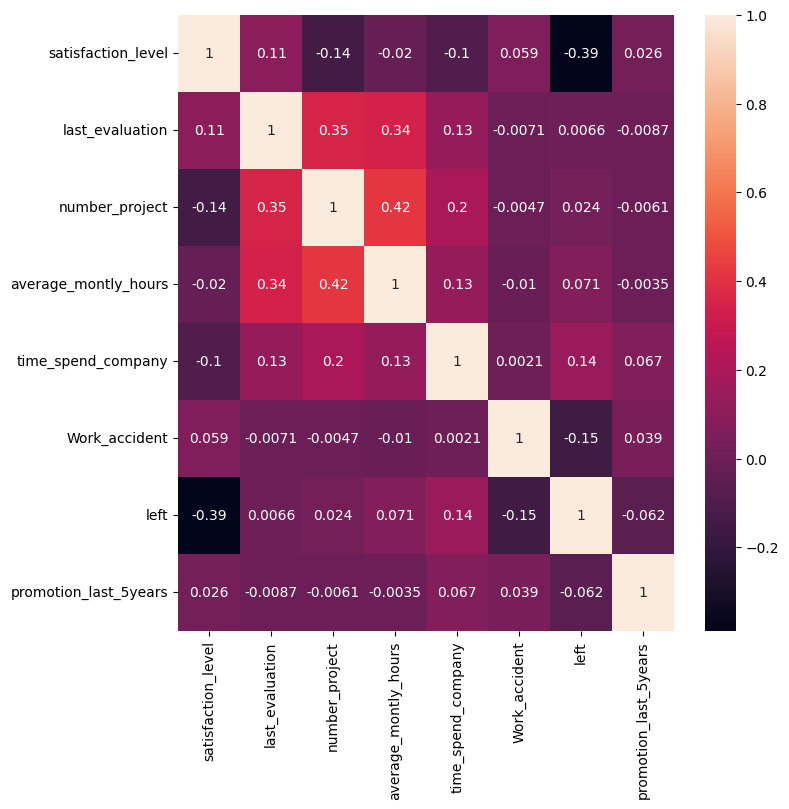

In [ ]:
plt.figure(figsize=(8,8))
sns.heatmap(numeric_df.corr(),annot=True)

In [ ]:
df1= df.groupby(["sales"])["left"].value_counts().reset_index(name="count")
df1= pd.DataFrame(df1)

In [ ]:
df["sales"].value_counts()

,count
sales,
sales,4140
technical,2720
support,2229
IT,1227
product_mng,902
marketing,858
RandD,787
accounting,767
hr,739


In [ ]:
dft= df["sales"].value_counts().reset_index(name="Total")

In [ ]:
dft= dft.rename(columns={"index":"sales"})

In [ ]:
dft

,sales,Total
0,sales,4140
1,technical,2720
2,support,2229
3,IT,1227
4,product_mng,902
5,marketing,858
6,RandD,787
7,accounting,767
8,hr,739
9,management,630


In [ ]:
dfmer= df1.merge(dft,how="left")
dfmer

,sales,left,count,Total
0,IT,0,954,1227
1,IT,1,273,1227
2,RandD,0,666,787
3,RandD,1,121,787
4,accounting,0,563,767
5,accounting,1,204,767
6,hr,0,524,739
7,hr,1,215,739
8,management,0,539,630
9,management,1,91,630


In [ ]:
dfmer["normal"]= dfmer["count"].div(dfmer["Total"].values)
dfmer["normal"]= dfmer["normal"]*100

In [ ]:
dfmer

,sales,left,count,Total,normal
0,IT,0,954,1227,77.750611
1,IT,1,273,1227,22.249389
2,RandD,0,666,787,84.625159
3,RandD,1,121,787,15.374841
4,accounting,0,563,767,73.402868
5,accounting,1,204,767,26.597132
6,hr,0,524,739,70.906631
7,hr,1,215,739,29.093369
8,management,0,539,630,85.555556
9,management,1,91,630,14.444444


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'IT'),
  Text(1, 0, 'RandD'),
  Text(2, 0, 'accounting'),
  Text(3, 0, 'hr'),
  Text(4, 0, 'management'),
  Text(5, 0, 'marketing'),
  Text(6, 0, 'product_mng'),
  Text(7, 0, 'sales'),
  Text(8, 0, 'support'),
  Text(9, 0, 'technical')])

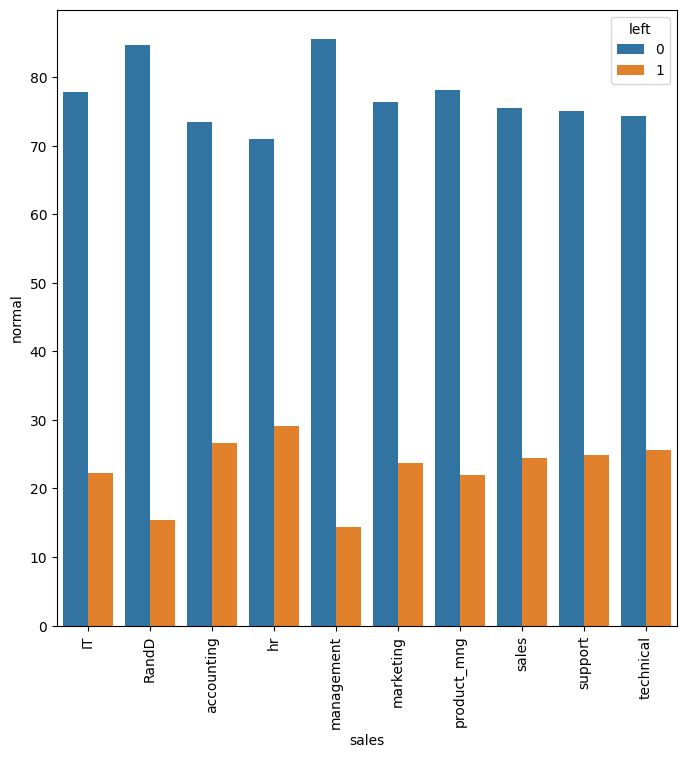

In [ ]:
plt.figure(figsize=(8,8))
sns.barplot(x="sales",y='normal',hue="left",data=dfmer)
plt.xticks(rotation=90)

In [ ]:
# People from the hr department are leaving the highest based on the normalized data.
# The hr department has the highest percentage.
# Normal=(Count of people from leaving category in a department)/(Total number of people in that department)*100

In [ ]:
df1.head()

,sales,left,count
0,IT,0,954
1,IT,1,273
2,RandD,0,666
3,RandD,1,121
4,accounting,0,563


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'IT'),
  Text(1, 0, 'RandD'),
  Text(2, 0, 'accounting'),
  Text(3, 0, 'hr'),
  Text(4, 0, 'management'),
  Text(5, 0, 'marketing'),
  Text(6, 0, 'product_mng'),
  Text(7, 0, 'sales'),
  Text(8, 0, 'support'),
  Text(9, 0, 'technical')])

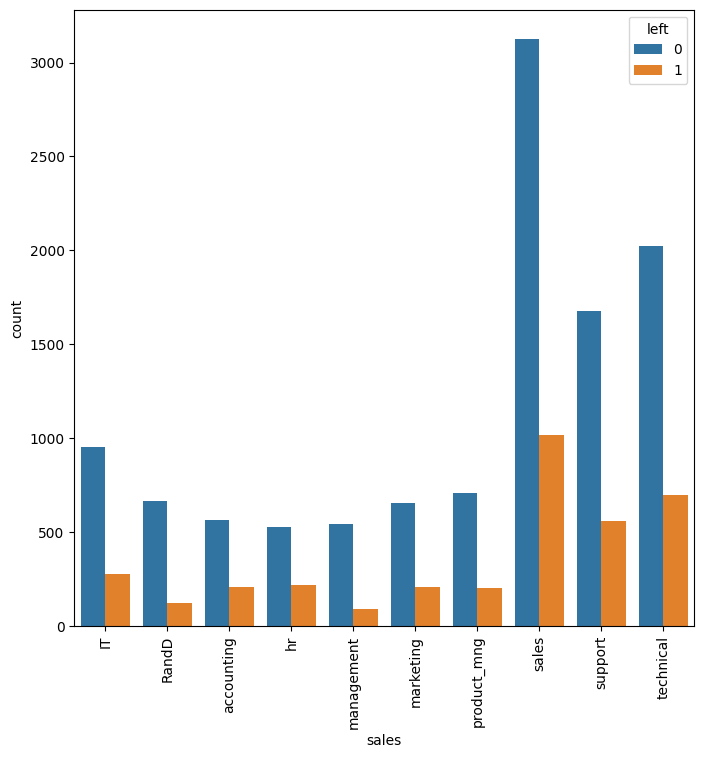

In [ ]:
plt.figure(figsize=(8,8))
sns.barplot(x="sales",y='count',hue="left",data=df1)
plt.xticks(rotation=90)

In [ ]:
# The people from the sales department are leaving the highest if we look at only the count of leaving people .

In [ ]:
df2= df.groupby(["salary"])["left"].value_counts().reset_index(name="count")
df2= pd.DataFrame(df2)

In [ ]:
df2.head()

,salary,left,count
0,high,0,1155
1,high,1,82
2,low,0,5144
3,low,1,2172
4,medium,0,5129


([0, 1, 2], [Text(0, 0, 'high'), Text(1, 0, 'low'), Text(2, 0, 'medium')])

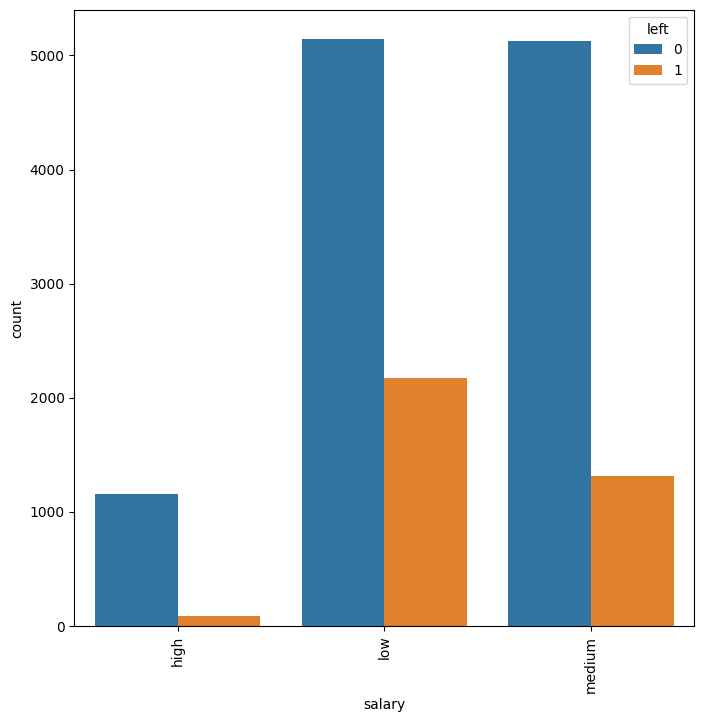

In [ ]:
plt.figure(figsize=(8,8))
sns.barplot(x="salary",y='count',hue="left",data=df2)
plt.xticks(rotation=90)

In [ ]:
# People with Lower Salaries are leaving the company.

In [ ]:
df3= df.groupby(["time_spend_company"])["left"].value_counts().reset_index(name="count")
df3= pd.DataFrame(df3)

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, '2'),
  Text(1, 0, '3'),
  Text(2, 0, '4'),
  Text(3, 0, '5'),
  Text(4, 0, '6'),
  Text(5, 0, '7'),
  Text(6, 0, '8'),
  Text(7, 0, '10')])

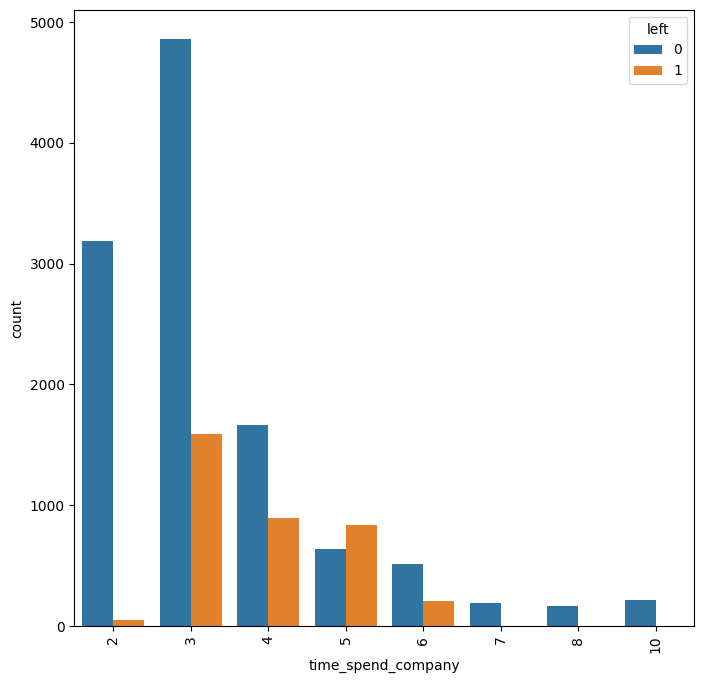

In [ ]:
# time_spend_company
plt.figure(figsize=(8,8))
sns.barplot(x="time_spend_company",y='count',hue="left",data=df3)
plt.xticks(rotation=90)

In [ ]:
# People with experience of 3 to 5 years are leaving the company more.

([0, 1], [Text(0, 0, '0'), Text(1, 0, '1')])

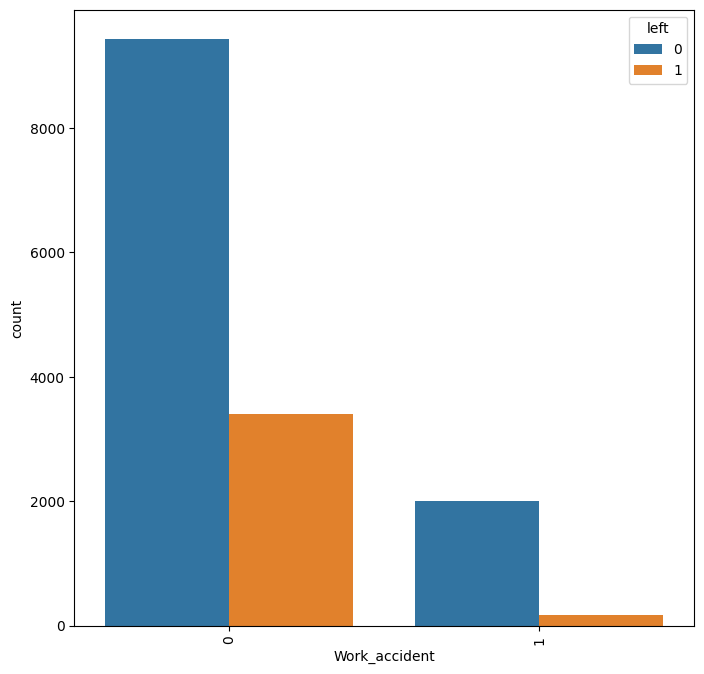

In [ ]:
plt.figure(figsize=(8,8))
sns.countplot(x="Work_accident",hue="left",data=df)
plt.xticks(rotation=90)

In [ ]:
df.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'sales', 'salary'],
      dtype='object')

(array([ 367., 1240., 2733., 1722., 1628., 1712., 1906., 2240., 1127.,
         324.]),
 array([ 96. , 117.4, 138.8, 160.2, 181.6, 203. , 224.4, 245.8, 267.2,
        288.6, 310. ]),
 <BarContainer object of 10 artists>)

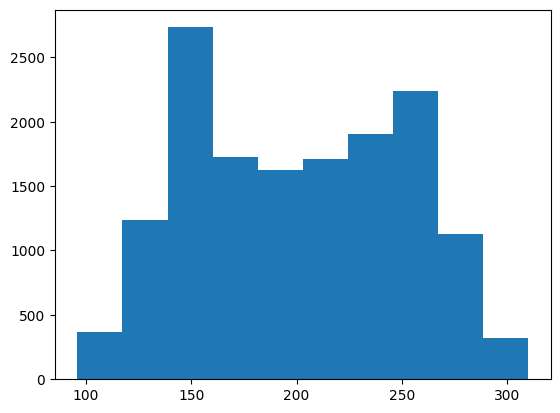

In [ ]:
plt.hist(df["average_montly_hours"])

<Axes: xlabel='average_montly_hours', ylabel='Count'>

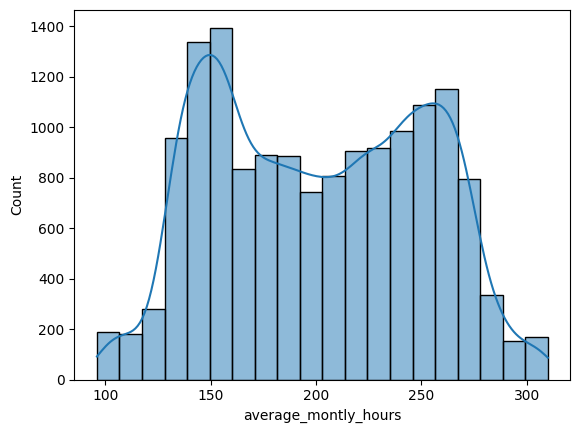

In [ ]:
sns.histplot(data=df,x="average_montly_hours",kde=True,bins=20)

<Axes: xlabel='satisfaction_level', ylabel='Count'>

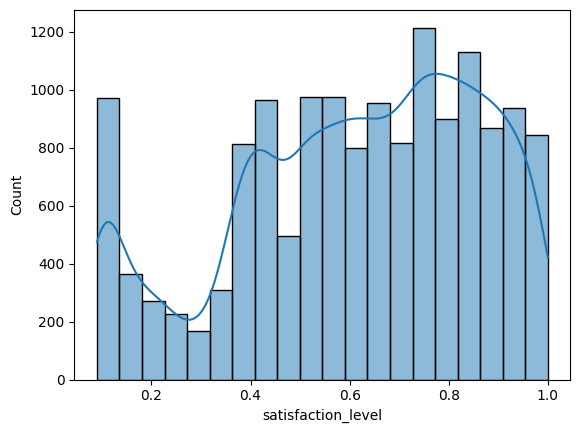

In [ ]:
sns.histplot(data=df,x="satisfaction_level",kde=True,bins=20)

<Axes: xlabel='last_evaluation', ylabel='Count'>

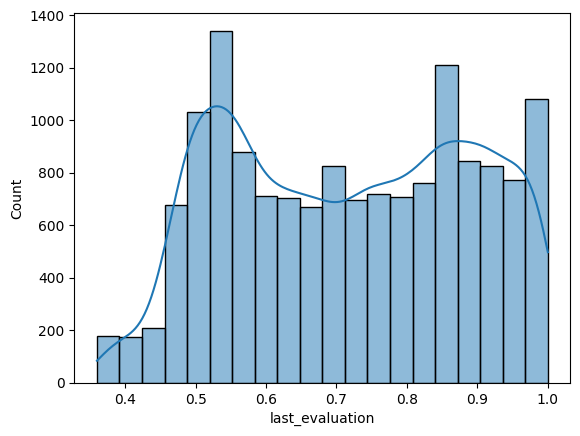

In [ ]:
sns.histplot(data=df,x="last_evaluation",kde=True,bins=20)

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, '2'),
  Text(1, 0, '3'),
  Text(2, 0, '4'),
  Text(3, 0, '5'),
  Text(4, 0, '6'),
  Text(5, 0, '7')])

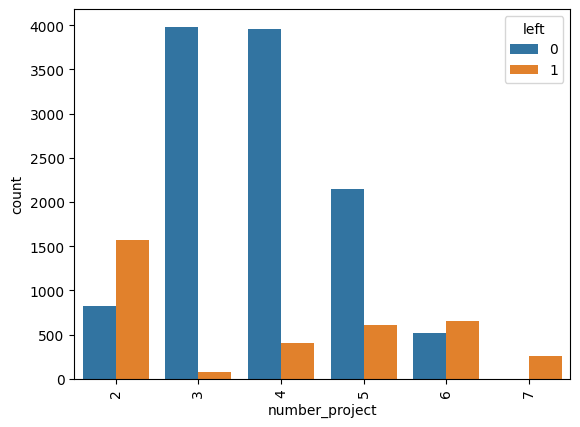

In [ ]:
sns.countplot(x="number_project",hue="left",data=df)
plt.xticks(rotation=90)

In [ ]:
# People who have worked on 3 or 4 projects have left the organisation more.

In [ ]:
dfclus= df[["satisfaction_level","last_evaluation","left"]]
dfclus

,satisfaction_level,last_evaluation,left
0,0.38,0.53,1
1,0.80,0.86,1
2,0.11,0.88,1
3,0.72,0.87,1
4,0.37,0.52,1
...,...,...,...
14994,0.40,0.57,1
14995,0.37,0.48,1
14996,0.37,0.53,1
14997,0.11,0.96,1


In [ ]:
from sklearn.cluster import KMeans

In [ ]:
km= dfclus.iloc[:,:].values
kmeans= KMeans(n_clusters=3,random_state=0)
label= kmeans.fit_predict(dfclus)
labelarr= kmeans.fit_predict(km)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [ ]:
label

array([1, 1, 1, ..., 1, 1, 1], dtype=int32)

In [ ]:
dfclus[label==0].describe()

,satisfaction_level,last_evaluation,left
count,4708.000000,4708.000000,4708.0
mean,0.457984,0.680854,0.0
std,0.153456,0.165609,0.0
min,0.120000,0.360000,0.0
25%,0.350000,0.550000,0.0
50%,0.510000,0.670000,0.0
75%,0.570000,0.810000,0.0
max,0.690000,1.000000,0.0


In [ ]:
dfclus[label==1].describe()

,satisfaction_level,last_evaluation,left
count,3571.000000,3571.000000,3571.0
mean,0.440098,0.718113,1.0
std,0.263933,0.197673,0.0
min,0.090000,0.450000,1.0
25%,0.130000,0.520000,1.0
50%,0.410000,0.790000,1.0
75%,0.730000,0.900000,1.0
max,0.920000,1.000000,1.0


In [ ]:
dfclus[label==2].describe()

,satisfaction_level,last_evaluation,left
count,6720.000000,6720.000000,6720.0
mean,0.813112,0.739728,0.0
std,0.108167,0.154900,0.0
min,0.590000,0.360000,0.0
25%,0.720000,0.610000,0.0
50%,0.810000,0.740000,0.0
75%,0.910000,0.870000,0.0
max,1.000000,1.000000,0.0


In [ ]:
km[label==0,1]

array([0.74, 0.69, 0.6 , ..., 0.94, 0.65, 0.73])

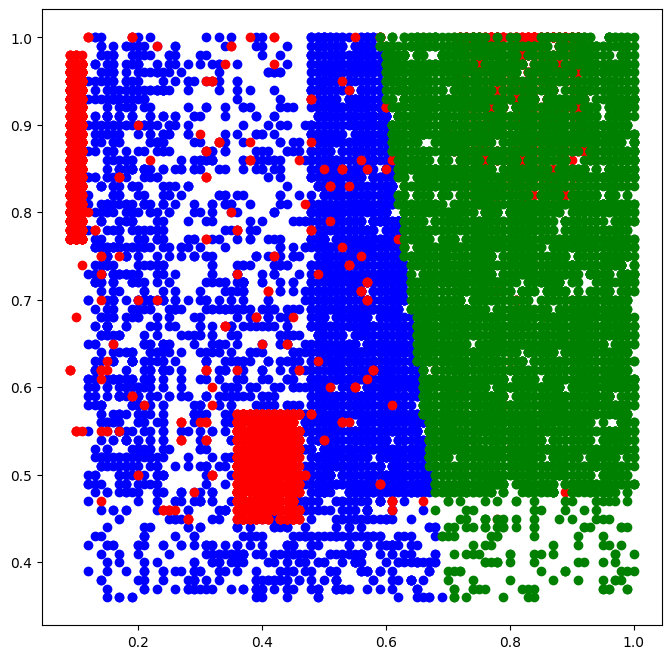

In [ ]:
plt.figure(figsize=(8,8))
plt.scatter(km[label==0,0],km[label==0,1],color="blue")
plt.scatter(km[label==1,0],km[label==1,1],color="red")
plt.scatter(km[label==2,0],km[label==2,1],color="green")

In [ ]:
# The Blue cluster denotes people with best satisfaction levels and scored high in the last evaluation.
# The Red cluster denotes people with medium satisfaction levels and scored average to high in the last evaluation.
# The Green cluster denotes people with lower satisfaction levels and scored fairly than the above mentioned clusters.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [ ]:
df_numerical= df.select_dtypes(include=['int64','float64'])
df_categorical= df.select_dtypes(include=['object'])

In [ ]:
# Converting the categorical data into numerical using one hot encoding.

In [ ]:
df_converted= pd.get_dummies(data=df_categorical)
df_converted.head()

,sales_IT,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_high,salary_low,salary_medium
0,False,False,False,False,False,False,False,True,False,False,False,True,False
1,False,False,False,False,False,False,False,True,False,False,False,False,True
2,False,False,False,False,False,False,False,True,False,False,False,False,True
3,False,False,False,False,False,False,False,True,False,False,False,True,False
4,False,False,False,False,False,False,False,True,False,False,False,True,False


In [ ]:
dfn= pd.concat([df_numerical,df_converted],axis=1,join="inner")
dfn.shape

(14999, 21)

In [ ]:
dfn.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales_IT,sales_RandD,...,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_high,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,False,False,...,False,False,False,False,True,False,False,False,True,False
1,0.80,0.86,5,262,6,0,1,0,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0.11,0.88,7,272,4,0,1,0,False,False,...,False,False,False,False,True,False,False,False,False,True
3,0.72,0.87,5,223,5,0,1,0,False,False,...,False,False,False,False,True,False,False,False,True,False
4,0.37,0.52,2,159,3,0,1,0,False,False,...,False,False,False,False,True,False,False,False,True,False


In [ ]:
# Splitting the dataset into training and testing in the ratio of 80:20 with random state=123

In [ ]:
x= dfn.drop("left",axis=1)
y= dfn["left"]

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
xtrain,xtest,ytrain,ytest= train_test_split(x,y,test_size=0.2,random_state=123)

In [ ]:
xtrain.shape,ytrain.shape,xtest.shape,ytest.shape

((11999, 20), (11999,), (3000, 20), (3000,))

In [ ]:
ytrain.value_counts()

,count
left,
0,9137
1,2862


In [ ]:
# Data is highly imbalanced for the training dataset as the record of people who left is very low in comparision to the record of people who didn't leave.
# Using SMOTE to handle the imbalance for the left category.

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
sm=SMOTE(random_state=2)
xtrainres,ytrainres= sm.fit_resample(xtrain,ytrain)

In [ ]:
ytrainres.value_counts()

,count
left,
0,9137
1,9137


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import sklearn.metrics as metrics

In [ ]:
logreg= LogisticRegression(solver='lbfgs',max_iter=10000)

In [ ]:
print(cross_val_score(logreg,xtrainres,ytrainres,cv=5).mean())

0.8052439280978364


In [ ]:
logreg.fit(xtrainres,ytrainres)
ypred=logreg.predict(xtest)

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
# Logistic Regression report

In [ ]:
metrics.confusion_matrix(ytest,ypred)

array([[1832,  459],
       [ 229,  480]])

In [ ]:
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.89      0.80      0.84      2291
           1       0.51      0.68      0.58       709

    accuracy                           0.77      3000
   macro avg       0.70      0.74      0.71      3000
weighted avg       0.80      0.77      0.78      3000



In [ ]:
roc_auc_score(ytest,ypred)

0.7383303402841437

In [ ]:
fpr,tpr,threshold= metrics.roc_curve(ytest,ypred)
print(fpr)
print(tpr)
print(threshold)
roc_auc= metrics.auc(fpr,tpr)
print(roc_auc)

[0.         0.20034919 1.        ]
[0.         0.67700987 1.        ]
[inf  1.  0.]
0.7383303402841437


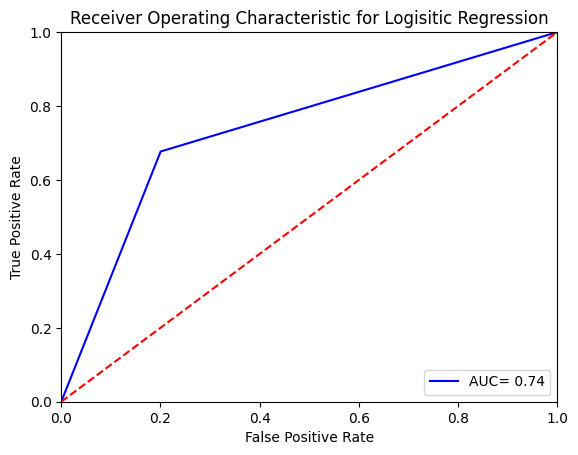

In [ ]:
# method I: plt
plt.title('Receiver Operating Characteristic for Logisitic Regression')
plt.plot(fpr,tpr,'b',label='AUC= %0.2f' % roc_auc)
plt.legend(loc='lower right')
plt.plot([0,1],[0,1],'r--')
plt.xlim([0,1])
plt.ylim([0,1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [ ]:
# Random Forest Classifier

In [ ]:
randm= RandomForestClassifier(max_depth=5)
print(cross_val_score(randm,xtrainres,ytrainres,cv=5).mean())

0.948779749269395


In [ ]:
randm.fit(xtrainres,ytrainres)
ypred1= randm.predict(xtest)

In [ ]:
# Random Forest Classification report

In [ ]:
metrics.confusion_matrix(ytest,ypred1)

array([[2214,   77],
       [  55,  654]])

In [ ]:
print(classification_report(ytest,ypred1))

              precision    recall  f1-score   support

           0       0.98      0.97      0.97      2291
           1       0.89      0.92      0.91       709

    accuracy                           0.96      3000
   macro avg       0.94      0.94      0.94      3000
weighted avg       0.96      0.96      0.96      3000



In [ ]:
roc_auc_score(ytest,ypred1)

0.9444080873276739

In [ ]:
fpr,tpr,threshold= metrics.roc_curve(ytest,ypred1)
print(fpr)
print(tpr)
print(threshold)
roc_auc= metrics.auc(fpr,tpr)
print(roc_auc)

[0.         0.03360978 1.        ]
[0.         0.92242595 1.        ]
[inf  1.  0.]
0.9444080873276739


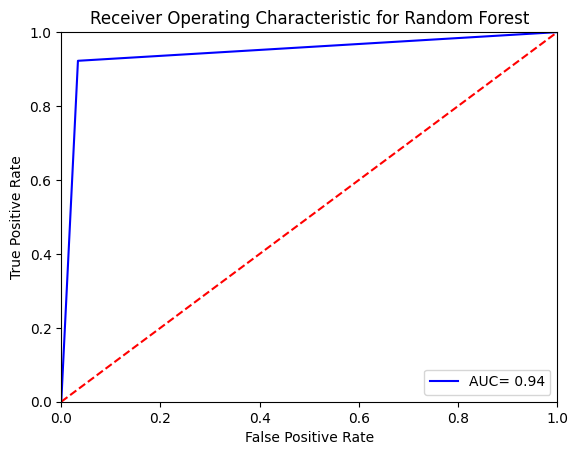

In [ ]:
# method I: plt
plt.title('Receiver Operating Characteristic for Random Forest')
plt.plot(fpr,tpr,'b',label='AUC= %0.2f' % roc_auc)
plt.legend(loc='lower right')
plt.plot([0,1],[0,1],'r--')
plt.xlim([0,1])
plt.ylim([0,1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [ ]:
# Gradient Boosting Classifier

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
gb= GradientBoostingClassifier(n_estimators=100,learning_rate=1.0,max_depth=1,random_state=0)

In [ ]:
print(cross_val_score(gb,xtrainres,ytrainres,cv=5).mean())

0.9479043560754963


In [ ]:
gb.fit(xtrainres,ytrainres)

GradientBoostingClassifier(learning_rate=1.0, max_depth=1, random_state=0)

In [ ]:
ypred2= gb.predict(xtest)

In [ ]:
# Gradient Boosting Classification Report

In [ ]:
metrics.confusion_matrix(ytest,ypred2)

array([[2168,  123],
       [  46,  663]])

In [ ]:
print(classification_report(ytest,ypred2))

              precision    recall  f1-score   support

           0       0.98      0.95      0.96      2291
           1       0.84      0.94      0.89       709

    accuracy                           0.94      3000
   macro avg       0.91      0.94      0.92      3000
weighted avg       0.95      0.94      0.94      3000



In [ ]:
roc_auc_score(ytest,ypred2)

0.9407157707322269

In [ ]:
fpr,tpr,threshold= metrics.roc_curve(ytest,ypred2)
print(fpr)
print(tpr)
print(threshold)
roc_auc= metrics.auc(fpr,tpr)
print(roc_auc)

[0.         0.05368835 1.        ]
[0.         0.93511989 1.        ]
[inf  1.  0.]
0.9407157707322269


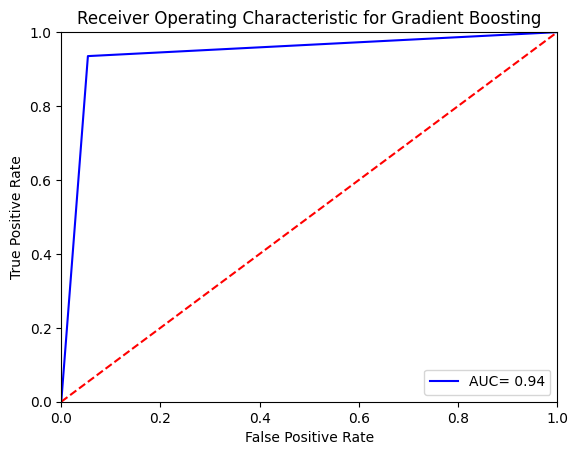

In [ ]:
# method I: plt
plt.title('Receiver Operating Characteristic for Gradient Boosting')
plt.plot(fpr,tpr,'b',label='AUC= %0.2f' % roc_auc)
plt.legend(loc='lower right')
plt.plot([0,1],[0,1],'r--')
plt.xlim([0,1])
plt.ylim([0,1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [ ]:
# Based on the confusion matrix, the false negatives should be low because if an employee who might leave the organisation is misclassified as someone
# who won't leave then proper strategies to retain that person will not be implemented on him or her. Hence Recall is better metric to be used

In [ ]:
col= xtrainres.columns
col

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident',
       'promotion_last_5years', 'sales_IT', 'sales_RandD', 'sales_accounting',
       'sales_hr', 'sales_management', 'sales_marketing', 'sales_product_mng',
       'sales_sales', 'sales_support', 'sales_technical', 'salary_high',
       'salary_low', 'salary_medium'],
      dtype='object')

In [ ]:
# Since Random Forest shows the highest accuracy with good f1 score, we will conclude that to be our best performing model.

In [ ]:
feature_labels= np.array(col)

In [ ]:
importance= randm.feature_importances_
feature_indexes_by_importance= importance.argsort()
for index in feature_indexes_by_importance:
  print('{}-{:.2f}%'.format(feature_labels[index],(importance[index] *100.0)))

sales_product_mng-0.00%
sales_marketing-0.01%
sales_management-0.02%
sales_RandD-0.03%
sales_accounting-0.03%
sales_IT-0.04%
sales_hr-0.08%
sales_support-0.09%
sales_sales-0.11%
promotion_last_5years-0.18%
sales_technical-0.24%
salary_medium-0.32%
salary_high-0.45%
salary_low-1.52%
Work_accident-3.28%
last_evaluation-11.62%
average_montly_hours-12.23%
number_project-16.63%
time_spend_company-25.14%
satisfaction_level-27.97%


In [ ]:
# The above lists the factors that influences the turnover in the ascending order. It can be identified that the employee turnover is highly influenced
# by the employee's satisfaction level in the organisation. Improvement of work culture within the organisation can be a good way to prevent the employees
# from leaving the organisation.

In [ ]:
predict_probability= randm.predict_proba(xtest)

In [ ]:
predict_probability[:,1]

array([0.04075687, 0.12361805, 0.08981619, ..., 0.73593545, 0.05440361,
       0.10403119])

In [ ]:
zone=[]
prob=[]

for i in predict_probability[:,1]:
  prob.append(i)
  if (i<=0.2):
    zone.append("Safe Zone")
  elif (i>0.2 and i<=0.6):
    zone.append("Low Risk Zone")
  elif (i>0.6 and i<=0.9):
    zone.append("Medium Risk Zone")
  else:
    zone.append("High Risk Zone")

In [ ]:
categories= ["Safe Zone","Low Risk Zone","Medium Risk Zone","High Risk Zone"]
color= ["Green","Yellow","Orange","Red"]
colordict= dict(zip(categories,color))

In [ ]:
clr= pd.DataFrame({"zone":zone,"probability":prob})
clr["zone"].unique()

array(['Safe Zone', 'High Risk Zone', 'Medium Risk Zone', 'Low Risk Zone'],
      dtype=object)

In [ ]:
clr["Color"]= clr["zone"].apply(lambda x: colordict[x])
clr.head(10)

,zone,probability,Color
0,Safe Zone,0.040757,Green
1,Safe Zone,0.123618,Green
2,Safe Zone,0.089816,Green
3,Safe Zone,0.084091,Green
4,Safe Zone,0.116136,Green
5,Safe Zone,0.059048,Green
6,High Risk Zone,0.945522,Red
7,Medium Risk Zone,0.766233,Orange
8,Safe Zone,0.149209,Green
9,Safe Zone,0.052470,Green


In [ ]:
color= clr["Color"].tolist()
c=["Green","Red","Orange","Yellow"]

<ipython-input-108-ab7a7b490aed>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(zone,palette=c)


<Axes: xlabel='count'>

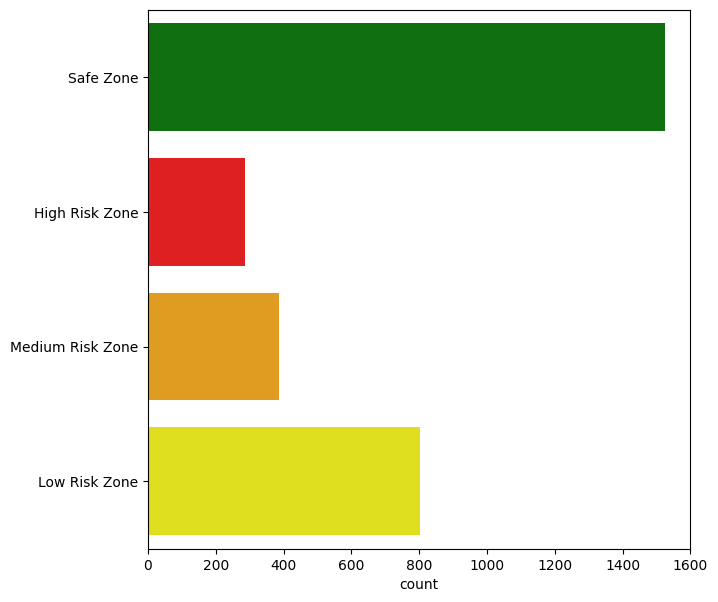

In [ ]:
plt.figure(figsize=(7,7))
sns.countplot(zone,palette=c)